In [1]:
%pip install gudhi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.0 MB/s eta 0:00:00


In [1]:
import numpy as np
import gudhi
import scipy.sparse as sp
from sklearn.cluster import KMeans

## Data

In [2]:
import plotly.graph_objects as go

def noisy_circle(x0, y0, z0=None, n=200, r=1.0, noise=0.1, plane="xy"):
    theta = np.linspace(0, 2*np.pi, n)

    x = x0 + r * np.cos(theta) + np.random.normal(0, noise, n)
    y = y0 + r * np.sin(theta) + np.random.normal(0, noise, n)
    if z0 is None:
        return x, y

    z = z0 + np.random.normal(0, noise, n)

    if plane == "yz":
        return z, x, y
    if plane == "xz":
        return x, z, y

    return x, y, z

def plot_cloud(x, y, z=None, size=2, save_as_svg_name=""):
    if z is None:
        fig = go.Figure(data=[go.Scatter(
            x=x, y=y,
            mode='markers',
            marker=dict(
                size=size*1.5
            )
        )])
        fig.update_xaxes(constrain='domain')
        fig.update_yaxes(scaleanchor="x", scaleratio=1)
    else:
        fig = go.Figure(data=[go.Scatter3d(
            x=x, y=y, z=z,
            mode='markers',
            marker=dict(
                size=size
            )
        )])

        fig.update_layout(
            scene=dict(
                aspectmode='data',
            ),
            margin=dict(l=0, r=0, t=0, b=0),
        )

    if save_as_svg_name:
        fig.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
        if z is None:
            fig.update_xaxes(visible=False)
            fig.update_yaxes(visible=False)
        else:
            fig.update_layout(
                scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False),
                showlegend=False, margin=dict(l=0, r=0, t=0, b=0))
        fig.write_image(f"{save_as_svg_name}.svg")
    fig.show()

In [3]:
def make_audi_cloud_2d(x0=0, y0=0, n=200, r=1.3, noise=0.1):
    c1 = np.stack(noisy_circle(0, 0, n=n, r=r, noise=noise), axis=1)
    c2 = np.stack(noisy_circle(2, 0, n=n, r=r, noise=noise), axis=1)
    c3 = np.stack(noisy_circle(4, 0, n=n, r=r, noise=noise), axis=1)
    c4 = np.stack(noisy_circle(6, 0, n=n, r=r, noise=noise), axis=1)
    return np.vstack((c1, c2, c3, c4)) + np.array([x0, y0])

def make_star_cloud_2d(x0=0, y0=0, n=200, r=1.3, noise=0.1):
    c1 = np.stack(noisy_circle(0, 0, n=n, r=r, noise=noise), axis=1)
    c2 = np.stack(noisy_circle(-np.sqrt(2*2-1**2), -1, n=n, r=r, noise=noise), axis=1)
    c3 = np.stack(noisy_circle(np.sqrt(2**2-1**2), -1, n=n, r=r, noise=noise), axis=1)
    c4 = np.stack(noisy_circle(0, 2, n=n, r=r, noise=noise), axis=1)
    return np.vstack((c1, c2, c3, c4)) + np.array([x0, y0])

def make_bracelet_cloud_3d(x0=0, y0=0, z0=0, n=100, r=1.3, inner_r=1, noise=0.1):
    c1 = np.stack(noisy_circle(0, 0, inner_r, n=n, r=r, noise=noise), axis=1)
    c2 = np.stack(noisy_circle(0, 0, -inner_r, n=n, r=r, noise=noise), axis=1)
    c3 = np.stack(noisy_circle(0, 0, inner_r, n=n, r=r, noise=noise, plane="xz"), axis=1)
    c4 = np.stack(noisy_circle(0, 0, -inner_r, n=n, r=r, noise=noise, plane="xz"), axis=1)
    return np.vstack((c1, c2, c3, c4)) + np.array([x0, y0, z0])

def make_one_point_cloud_3d(x0=0, y0=0, z0=0, n=200, r=1.3, noise=0.1):
    c1 = np.stack(noisy_circle(0, r, 0, n=n, r=r, noise=noise), axis=1)
    c2 = np.stack(noisy_circle(0, -r, 0, n=n, r=r, noise=noise), axis=1)
    c3 = np.stack(noisy_circle(0, r, 0, n=n, r=r, noise=noise, plane="xz"), axis=1)
    c4 = np.stack(noisy_circle(0, -r, 0, n=n, r=r, noise=noise, plane="xz"), axis=1)
    return np.vstack((c1, c2, c3, c4)) + np.array([x0, y0, z0])

def make_sphere_cloud_3d(x0=0, y0=0, z0=0, n=200, r=2.6, noise=0.01):
    points = np.random.normal(0, 1, (n, 3))
    norms = np.linalg.norm(points, axis=1, keepdims=True)

    noise = np.random.normal(0, noise, (n, 3))
    return (points / norms) * r + np.array([x0, y0, z0]) + noise

In [4]:
# for image saving
# %pip install kaleido==0.2.1

## Harmonic component

In [5]:
def compute_simplices(simplex_tree, max_dim):
    k_simplices = [[] for i in range(max_dim + 1)]
    for simplex, filtration in simplex_tree.get_simplices():
        k_simplices[len(simplex) - 1].append(simplex)

    k_simplices_dict = []
    for i in range(max_dim + 1):
        k_simplices_dict.append(
            dict(
                zip(
                    [str(simplex) for simplex in k_simplices[i]],
                    range(len(k_simplices[i])),
                )
            )
        )
    return k_simplices, k_simplices_dict

In [6]:
def compute_boundary_operators(k_simplices, k_simplices_dict, max_dim):
    boundary_operators = []
    for k in range(max_dim):
        inds_v = []
        inds_u = []
        values = []
        for simplex_u in k_simplices[k + 1]:
            ind_u = k_simplices_dict[k + 1][str(simplex_u)]

            for i in range(k + 2):
                simplex_v = simplex_u.copy()
                simplex_v.pop(i)
                ind_v = k_simplices_dict[k][str(simplex_v)]

                inds_v.append(ind_v)
                inds_u.append(ind_u)
                if i % 2:
                    values.append(1)
                else:
                    values.append(-1)

        boundary_operators.append(
            sp.csc_matrix(
                (np.array(values), (np.array(inds_v), np.array(inds_u))),
                shape=(len(k_simplices[k]), len(k_simplices[k + 1])),
                dtype=float,
            )
        )
    return boundary_operators

In [7]:
def compute_harmonic_basis(L, k=20, tol=1e-8):
    """
    Find harmonic basis vectors as null space of Laplacian L.
    """
    n = L.shape[0]
    k = min(k, n - 2)
    eigenvalues, eigenvectors = sp.linalg.eigsh(L, k=k, sigma=0, which='LM', tol=1e-12)
    harmonic_mask = np.abs(eigenvalues) < tol
    return eigenvectors[:, harmonic_mask], eigenvalues[harmonic_mask]

In [8]:
def compute_all_harmonic_bases(boundary_operators, tol=1e-8, k=20):
    results = {}
    n_dims = len(boundary_operators)

    for d in range(n_dims):
        # Lower term: B_{d-1}^T B_{d-1}  (= 0 if d==0)
        lower = boundary_operators[d-1].T @ boundary_operators[d-1] if d > 0 else 0
        # Upper term: B_d B_d^T
        upper = boundary_operators[d] @ boundary_operators[d].T
        L = lower + upper

        basis, eigs = compute_harmonic_basis(L, k=k, tol=tol)
        results[f"H{d}"] = np.abs(basis) / np.max(np.abs(basis) + 1e-13)
        print(f"Betti_{d} = {basis.shape[1]}")

    return results

In [9]:
def compute_point_signatures(harmonic_basis, boundary_operators):
    """
    harmonic_basis: dict {"H0": mat0, "H1": mat1, "H2": mat2, "H3": mat3, ...}
    boundary_operators: list [B0, B1, B2, B3, ...]
    """
    n_points = boundary_operators[0].shape[0]
    parts = []
    feature_dim = []

    current_projection = sp.eye(n_points)

    for d in range(len(harmonic_basis)):
        Hd = np.abs(harmonic_basis[f"H{d}"])

        numerator = current_projection @ Hd
        denominator = np.array(current_projection.sum(axis=1)) + 1e-13  # normalizing by degree
        parts.append(numerator / denominator)
        feature_dim.extend([d] * len(parts[-1][0]))

        current_projection = current_projection @ np.abs(boundary_operators[d])

    return np.hstack(parts), np.array(feature_dim)

In [ ]:
audi_cloud_2d = make_audi_cloud_2d()
plot_cloud(audi_cloud_2d[:, 0], audi_cloud_2d[:, 1])

In [ ]:
cloud = audi_cloud_2d

In [ ]:
max_edge_len = 1
max_dim = 2

rips_complex = gudhi.RipsComplex(points=cloud, max_edge_length=max_edge_len)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=max_dim)

In [ ]:
k_simplices, k_simplices_dict = compute_simplices(simplex_tree, max_dim)

In [ ]:
boundary_operators = compute_boundary_operators(k_simplices, k_simplices_dict, max_dim)

In [ ]:
boundary_operators

[<Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 63436 stored elements and shape (800, 31718)>,
 <Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 1940796 stored elements and shape (31718, 646932)>]

In [ ]:
harm_component = compute_all_harmonic_bases(boundary_operators)

Betti_0 = 1
Betti_1 = 4


In [ ]:
harm_component["H1"].shape

(31718, 4)

In [ ]:
signatures, feature_dim = compute_point_signatures(harm_component, boundary_operators)

In [ ]:
feature_dim

array([0, 1, 1, 1, 1])

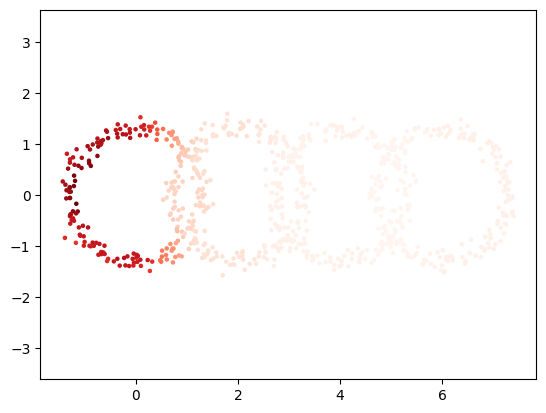

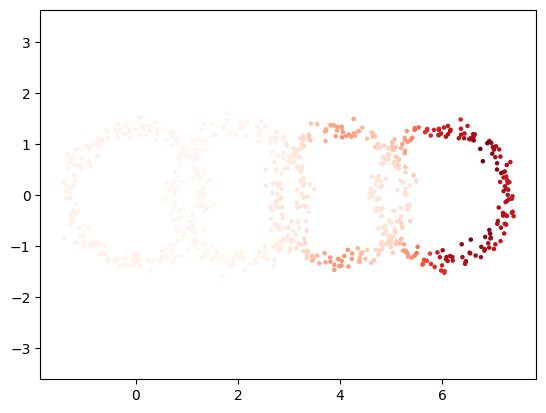

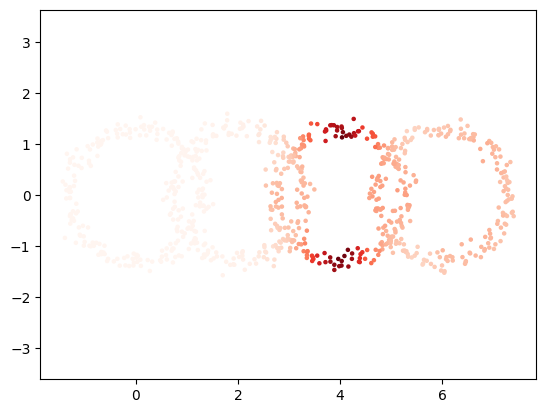

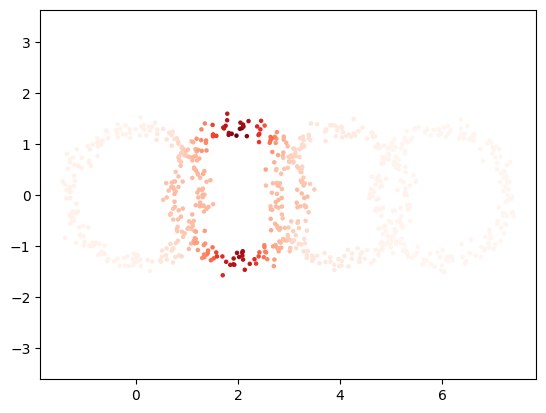

In [ ]:
import matplotlib.pyplot as plt

for i in range(1, signatures.shape[1]):
    plt.scatter(cloud[:, 0], cloud[:, 1], s=5, c=signatures[:, i], cmap="Reds")
    plt.axis('equal')
    plt.show()

In [ ]:
# number of clusters = number of cycles, e.g. vectors in H1
clustering = KMeans(signatures.shape[1]-1).fit(signatures)

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure()

for label in np.unique(clustering.labels_):
    vertex_subset = cloud[clustering.labels_ == label]

    fig.add_trace(go.Scatter(
        x=vertex_subset[:, 0], y=vertex_subset[:, 1],
        mode='markers',
        name=f'Group {label}'
    ))

fig.show()

## Topological Intersection Graph

In [10]:
_DIM_COLORS = {0: "cadetblue", 1: "chocolate", 2: "darkorchid"}
_DIM_LABELS = {0: "H0 component", 1: "H1 loop", 2: "H2 void"}


def intersection_graph(
    points, top_features, labels, feature_dim,
    edge_threshold=0.15, show_cloud=True, point_s_factor=1,
    similarity="cosine",
    title="Topological Intersection Graph",
    save_as_svg_name=""
):
    """
    Visualises cluster-to-cluster topological intersection confidence.

    Parameters
    ----------
    points : np.ndarray (N, 2|3)
        Original point cloud.  Node positions are cluster centroids.
    top_features : np.ndarray (N, F)
        Topological features from topf(return_dict=True).
    labels : np.ndarray (N,)
        Cluster labels from topf(return_dict=True)["labels"].
    feature_dim : array-like (F,)
        Homology dimension of each feature column, from
        topf(return_dict=True)["feature_dim"].
    edge_threshold : float
        Minimum similarity to draw an edge.
    show_cloud : bool
        Overlay a faint point cloud for spatial reference.
    similarity : {"cosine", "dot"}
        "cosine" — normalised dot product in [-1,1], clipped to >=0.
        "dot" — raw dot product.
    title : str

    Returns
    -------
    W : np.ndarray (K, K)
        Symmetric similarity matrix between cluster mean feature vectors
        (diagonal zero).
    """
    K = int(labels.max()) + 1
    F = top_features.shape[1]
    is3 = points.shape[1] == 3
    feature_dim = np.asarray(feature_dim)

    # per-cluster statistics
    centroids = np.array([points[labels == k].mean(0) for k in range(K)])
    sizes = np.array([(labels == k).sum() for k in range(K)])
    means = np.array([
        top_features[labels == k].mean(0) if (labels == k).any() else np.zeros(F)
        for k in range(K)
    ])

    # dominant homology dimension per cluster
    dominant = np.array([
        max(
            {d: means[k, feature_dim == d].sum() for d in np.unique(feature_dim)},
            key=lambda d: means[k, feature_dim == d].sum(),
        ) if F else 0
        for k in range(K)
    ], dtype=int)

    # similarity matrix
    if similarity == "cosine":
        normed = means / (np.linalg.norm(means, axis=1, keepdims=True) + 1e-12)
        W = np.clip(normed @ normed.T, 0, 1)
    else:  # dot
        W = means @ means.T

    np.fill_diagonal(W, 0.0)
    max_w = W.max() or 1.0

    fig = go.Figure()

    # background point cloud
    if show_cloud:
        cloud_marker = dict(
            size=(1.5 if is3 else 3)*point_s_factor,
            color=labels,
            colorscale="Portland",
            opacity=0.9,
        )
        scatter_cls = go.Scatter3d if is3 else go.Scatter
        coords = dict(x=points[:, 0], y=points[:, 1])
        if is3:
            coords["z"] = points[:, 2]
        fig.add_trace(scatter_cls(
            **coords, mode="markers",
            marker=cloud_marker, hoverinfo="skip", showlegend=False,
        ))

    # edges
    for i in range(K):
        for j in range(i + 1, K):
            w = W[i, j]
            if w < edge_threshold:
                continue

            width_rel = w / max_w
            color = f"rgba(128,128,128,1)"
            mid = (centroids[i] + centroids[j]) / 2
            ht = f"C{i} ↔ C{j}<br>sim={w:.3f}<extra></extra>"

            if is3:
                fig.add_trace(go.Scatter3d(
                    x=[centroids[i, 0], centroids[j, 0], None],
                    y=[centroids[i, 1], centroids[j, 1], None],
                    z=[centroids[i, 2], centroids[j, 2], None],
                    mode="lines",
                    line=dict(color=color, width=10*width_rel),
                    hovertemplate=ht, showlegend=False,
                ))
            else:
                fig.add_trace(go.Scatter(
                    x=[centroids[i, 0], centroids[j, 0]],
                    y=[centroids[i, 1], centroids[j, 1]],
                    mode="lines",
                    line=dict(color=color, width=5*width_rel),
                    hovertemplate=ht, showlegend=False,
                ))
                fig.add_annotation(
                    x=mid[0], y=mid[1], text=f"{w:.2f}",
                    showarrow=False,
                    font=dict(size=9, color="rgba(180,178,172,1)"),
                    bgcolor="rgba(23,22,20,0.85)", borderpad=2,
                )

    # nodes
    for k in range(K):
        mk = dict(
            size=40*np.sqrt(sizes[k] / sizes.max()),
            color=_DIM_COLORS[dominant[k]],
            line=dict(width=3 if is3 else 1.5)
        )
        ht = (
            f"<b>Cluster {k}</b><br>N={sizes[k]}<br>"
            f"Dominant: {_DIM_LABELS.get(dominant[k], f'H{dominant[k]}')}<br><extra></extra>"
        )

        if is3:
            fig.add_trace(go.Scatter3d(
                x=[centroids[k, 0]], y=[centroids[k, 1]], z=[centroids[k, 2]],
                mode="markers+text", marker=mk,
                text=[f"C{k}"], textposition="top center",
                hovertemplate=ht, showlegend=False,
            ))
        else:
            fig.add_trace(go.Scatter(
                x=[centroids[k, 0]], y=[centroids[k, 1]],
                mode="markers+text", marker=mk,
                text=[f"C{k}"], textposition="top center",
                hovertemplate=ht, showlegend=False,
            ))

    # H0, H1, H2 legend
    for i, (d, c) in enumerate(_DIM_COLORS.items()):
        fig.add_annotation(
            xref="paper", yref="paper", x=1.1, y=0.95 - i * 0.08,
            text=f"<span style='color:{c}'>● {_DIM_LABELS[d]}</span>",
            showarrow=False, align="left"
        )

    if is3:
        fig.update_layout(scene=dict(
            aspectmode="data",
            xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
        ))
    else:
        fig.update_xaxes(visible=False, constrain="domain")
        fig.update_yaxes(visible=False, scaleanchor="x", scaleratio=1)

    fig.update_layout(
        title=dict(text=title),
         margin=dict(l=0, r=150, t=50, b=0)
    )
    if save_as_svg_name:
        fig.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
        fig.update_layout(showlegend=False, margin=dict(l=0, r=0, t=0, b=0))
        fig.write_image(f"{save_as_svg_name}.svg")
    fig.show()
    return W

In [ ]:
similarity_matrix = intersection_graph(cloud, signatures[:, 1:], clustering.labels_, feature_dim[1:])

In [ ]:
%pip install topf

In [ ]:
import topf

In [ ]:
features, topf_dict = topf.topf(cloud, return_dict=True)

In [ ]:
similarity_matrix = intersection_graph(cloud, features, topf_dict["labels"], topf_dict["feature_dim"])

## Cohomology

In [11]:
import numpy as np
import plotly.graph_objects as go


_DIM_COLORS = {0: "cadetblue", 1: "chocolate", 2: "darkorchid"}
_DIM_LABELS = {0: "H0 component", 1: "H1 loop", 2: "H2 void"}

# edge color by pair type
_EDGE_COLORS = {
    (1, 1): "rgba(210,140,70,0.9)",   # loop-loop
    (1, 2): "rgba(181,77,117,0.9)",  # loop-void
    (2, 2): "rgba(170,110,200,0.9)",   # void-void
}


def _cosine(a, b, eps=1e-12):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < eps or nb < eps:
        return 0.0
    return float(np.clip(np.dot(a, b) / (na * nb), 0.0, 1.0))


def _dot(a, b):
    return float(np.dot(a, b))


def cap(alpha, beta, K):
    """
    Cap product of two H1 cocycles alpha, beta on edges,
    pushed back to vertices via the second endpoint of each edge.
    K = (vertices, edges, triangles)
    """
    gamma = np.zeros(len(K[0]))
    for i, edge in enumerate(K[1]):
        u, v = edge
        vertex_back_idx = K[0].index(v)
        gamma[vertex_back_idx] += alpha[i] * beta[i]
    return gamma


def _topk_centroid(simplices_coords, weights, top_frac=0.1):
    """
    simplices_coords : (M, d) array, geometric centroid of each simplex
    weights          : (M,) non-negative magnitudes
    top_frac         : keep top fraction by weight (>=1 simplex)
    """
    M = len(weights)
    k = max(1, int(np.ceil(top_frac * M)))
    idx = np.argpartition(-weights, k - 1)[:k]
    w = weights[idx]
    if w.sum() < 1e-12:
        return simplices_coords[idx].mean(0)
    return (simplices_coords[idx] * w[:, None]).sum(0) / w.sum()


def intersection_graph_harmonic(
    points,
    harmonic_basis,
    boundary_operators,
    k_simplices,
    edge_threshold=0.1,
    similarity="cosine",          # {"cosine", "dot", "cap"}
    top_frac=0.1,
    show_cloud=True,
    cloud_opacity=0.8,
    labels=None,
    point_s_factor=1,
    title="Topological Intersection Graph (harmonic)",
    save_as_svg_name=""
):
    """
    Build an intersection graph where each node is an individual H1 loop or
    H2 void, located at the weighted centroid of its dominant simplices.

    Parameters
    ----------
    points : (N, 2|3) array
    harmonic_basis : dict with keys "H1" (E, n1) and optionally "H2" (T, n2)
    boundary_operators : list [B0, B1, B2, ...]
        B1 has shape (E, T) and is used to push H2 voids onto edges
        for the loop-void similarity.
    k_simplices : list as returned by compute_simplices.
        k_simplices[0] : vertices, k_simplices[1] : edges, k_simplices[2] : triangles
    similarity : {"cosine", "dot", "cap"}
        "cap" requires every node to be H1; otherwise it falls back
        to "cosine" automatically.
    labels : np.ndarray (N,)
        Cluster labels for cloud coloring.
    """
    is3 = points.shape[1] == 3
    points = np.asarray(points)

    H1 = harmonic_basis.get("H1", np.zeros((0, 0)))
    H2 = harmonic_basis.get("H2", np.zeros((0, 0)))
    n1 = H1.shape[1]
    n2 = H2.shape[1]

    # geometric centroids of each simplex
    edge_coords = np.array([points[list(e)].mean(0) for e in k_simplices[1]]) \
        if len(k_simplices) > 1 and len(k_simplices[1]) else np.zeros((0, points.shape[1]))
    tri_coords = np.array([points[list(t)].mean(0) for t in k_simplices[2]]) \
        if len(k_simplices) > 2 and len(k_simplices[2]) else np.zeros((0, points.shape[1]))

    # node centers + dominant dim
    centers = []
    dominant = []   # 1 for loop, 2 for void
    sources = []    # ("H1", i) or ("H2", j)

    for i in range(n1):
        w = np.abs(H1[:, i])
        centers.append(_topk_centroid(edge_coords, w, top_frac=top_frac))
        dominant.append(1)
        sources.append(("H1", i))

    for j in range(n2):
        w = np.abs(H2[:, j])
        centers.append(_topk_centroid(tri_coords, w, top_frac=top_frac))
        dominant.append(2)
        sources.append(("H2", j))

    centers = np.array(centers) if len(centers) else np.zeros((0, points.shape[1]))
    dominant = np.array(dominant, dtype=int)
    K = len(centers)

    # feature_dim = dominant dim of every node, used by cap gating
    feature_dim = dominant.copy()

    # similarity selection — cap is only valid if every node is H1
    sim_mode = similarity
    if sim_mode == "cap" and not np.all(feature_dim == 1):
        sim_mode = "cosine"
        print("Not all components are loops -> switching from cap to cosine")

    sim_fn = _cosine if sim_mode != "dot" else _dot

    # B1 used to push voids onto edges for loop-void similarity
    B1 = boundary_operators[1] if len(boundary_operators) > 1 else None
    B1H2 = (B1 @ H2) if (B1 is not None and n2 > 0) else None  # (E, n2)

    # cap needs (vertices, edges, triangles)
    if sim_mode == "cap":
        vertices = [v[0] for v in k_simplices[0]]
        edges = [tuple(v) for v in k_simplices[1]]
        triangles = [tuple(v) for v in k_simplices[2]] if len(k_simplices) > 2 else []
        K_simp = (vertices, edges, triangles)

    # similarity matrix
    W = np.zeros((K, K))
    pair_kind = np.zeros((K, K), dtype=int)  # encoded type per edge

    for a in range(K):
        sa, ia = sources[a]
        for b in range(a + 1, K):
            sb, ib = sources[b]

            if sa == "H1" and sb == "H1":
                if sim_mode == "cap":
                    gamma = cap(H1[:, ia], H1[:, ib], K_simp)
                    w = np.linalg.norm(gamma)
                else:
                    w = sim_fn(H1[:, ia], H1[:, ib])
                kind = (1, 1)

            elif sa == "H1" and sb == "H2":
                w = sim_fn(H1[:, ia], B1H2[:, ib]) if B1H2 is not None else 0.0
                kind = (1, 2)

            elif sa == "H2" and sb == "H1":
                w = sim_fn(B1H2[:, ib], H2[:, ia]) if B1H2 is not None else 0.0
                kind = (1, 2)

            else:  # both H2
                w = sim_fn(H2[:, ia], H2[:, ib])
                kind = (2, 2)

            W[a, b] = W[b, a] = w
            code = kind[0] * 10 + kind[1]
            pair_kind[a, b] = pair_kind[b, a] = code

    np.fill_diagonal(W, 0.0)
    max_w = W.max() or 1.0

    # node sizes — proportional to mass of the corresponding cocycle
    masses = np.array([
        np.abs(H1[:, ia]).sum() if s == "H1" else np.abs(H2[:, ia]).sum()
        for (s, ia) in sources
    ]) if K else np.array([1.0])
    masses = masses / (masses.max() + 1e-12)

    fig = go.Figure()

    # background point cloud
    if show_cloud:
        cloud_marker = dict(
            size=(1.5 if is3 else 3)*point_s_factor,
            color="lightgray" if labels is None else labels,
            colorscale="Portland",
            opacity=cloud_opacity,
        )
        scatter_cls = go.Scatter3d if is3 else go.Scatter
        coords = dict(x=points[:, 0], y=points[:, 1])
        if is3:
            coords["z"] = points[:, 2]
        fig.add_trace(scatter_cls(
            **coords, mode="markers",
            marker=cloud_marker, hoverinfo="skip", showlegend=False,
        ))

    # edges
    for i in range(K):
        for j in range(i + 1, K):
            w = W[i, j]
            if w < edge_threshold:
                continue

            width_rel = w / max_w
            code = pair_kind[i, j]
            kind_tuple = (code // 10, code % 10)
            color = _EDGE_COLORS.get(kind_tuple, "rgba(128,128,128,1)")
            mid = (centers[i] + centers[j]) / 2

            label_a = f"{sources[i][0]}#{sources[i][1]}"
            label_b = f"{sources[j][0]}#{sources[j][1]}"
            ht = (f"C{i} ↔ C{j}<br>"
                  f"sim={w:.3f} ({sim_mode})<extra></extra>")

            if is3:
                fig.add_trace(go.Scatter3d(
                    x=[centers[i, 0], centers[j, 0], None],
                    y=[centers[i, 1], centers[j, 1], None],
                    z=[centers[i, 2], centers[j, 2], None],
                    mode="lines",
                    line=dict(color=color, width=10 * width_rel),
                    opacity=float(np.clip(0.3 + 0.7 * width_rel, 0, 1)),
                    hovertemplate=ht, showlegend=False,
                ))
            else:
                fig.add_trace(go.Scatter(
                    x=[centers[i, 0], centers[j, 0]],
                    y=[centers[i, 1], centers[j, 1]],
                    mode="lines",
                    line=dict(color=color, width=5 * width_rel),
                    opacity=float(np.clip(0.3 + 0.7 * width_rel, 0, 1)),
                    hovertemplate=ht, showlegend=False,
                ))
                fig.add_annotation(
                    x=mid[0], y=mid[1], text=f"{w:.2f}",
                    showarrow=False,
                    font=dict(size=9, color="rgba(180,178,172,1)"),
                    bgcolor="rgba(23,22,20,0.85)", borderpad=2,
                )

    # nodes
    for k in range(K):
        d = dominant[k]
        mk = dict(
            size=40 * np.sqrt(masses[k]),
            color=_DIM_COLORS[d],
            line=dict(width=3 if is3 else 1.5),
        )
        s, ia = sources[k]
        # ht = (f"<b>{s} #{ia}</b><br>"
        #       f"{_DIM_LABELS[d]}<br><extra></extra>")
        ht = (
            f"<b>Cluster {k}</b><br>"
            f"Dominant: {_DIM_LABELS.get(dominant[k], f'H{dominant[k]}')}<br><extra></extra>"
        )

        if is3:
            fig.add_trace(go.Scatter3d(
                x=[centers[k, 0]], y=[centers[k, 1]], z=[centers[k, 2]],
                mode="markers+text", marker=mk,
                text=[f"C{k}"], textposition="top center",
                hovertemplate=ht, showlegend=False,
            ))
        else:
            fig.add_trace(go.Scatter(
                x=[centers[k, 0]], y=[centers[k, 1]],
                mode="markers+text", marker=mk,
                text=[f"C{k}"], textposition="top center",
                hovertemplate=ht, showlegend=False,
            ))

    # legend (dims + edge types)
    if not save_as_svg_name:
        for i, d in enumerate([1, 2]):
            fig.add_annotation(
                xref="paper", yref="paper", x=1.1, y=0.95 - i * 0.06,
                text=f"<span style='color:{_DIM_COLORS[d]}'>● {_DIM_LABELS[d]}</span>",
                showarrow=False, align="left",
            )
        for i, (kind, c) in enumerate(_EDGE_COLORS.items()):
            name = {(1, 1): "loop–loop", (1, 2): "loop–void", (2, 2): "void–void"}[kind]
            fig.add_annotation(
                xref="paper", yref="paper", x=1.1, y=0.75 - i * 0.06,
                text=f"<span style='color:{c}'>━ {name}</span>",
                showarrow=False, align="left",
            )
        fig.add_annotation(
            xref="paper", yref="paper", x=1.1, y=0.55,
            text=f"similarity: <b>{sim_mode}</b>",
            showarrow=False, align="left",
        )

    if is3:
        fig.update_layout(scene=dict(
            aspectmode="data",
            xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
        ))
    else:
        fig.update_xaxes(visible=False, constrain="domain")
        fig.update_yaxes(visible=False, scaleanchor="x", scaleratio=1)

    if save_as_svg_name:
        fig.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
        fig.update_layout(showlegend=False, margin=dict(l=0, r=0, t=0, b=0))
        fig.write_image(f"{save_as_svg_name}.svg")
    else:
        fig.update_layout(
        title=dict(text=f"{title} — {sim_mode}"),
        margin=dict(l=0, r=180, t=50, b=0),
        )
    fig.show()
    return W

In [ ]:
W = intersection_graph_harmonic(
    points=cloud,
    harmonic_basis=harm_component,
    boundary_operators=boundary_operators,
    k_simplices=k_simplices,
    edge_threshold=0.15,
    similarity="cosine",
    top_frac=0.1,
    labels=clustering.labels_
)

In [ ]:
W = intersection_graph_harmonic(
    points=cloud,
    harmonic_basis=harm_component,
    boundary_operators=boundary_operators,
    k_simplices=k_simplices,
    edge_threshold=10,
    similarity="cap",
    top_frac=0.1,
    labels=clustering.labels_
)

In [ ]:
W

array([[ 0.        ,  3.22362819,  2.0371206 , 10.77776465],
       [ 3.22362819,  0.        , 27.38365633,  4.34544404],
       [ 2.0371206 , 27.38365633,  0.        , 10.50020524],
       [10.77776465,  4.34544404, 10.50020524,  0.        ]])

## Other examples

In [12]:
def run_hodge(cloud, max_edge_len=1, max_dim=2):
    rips_complex = gudhi.RipsComplex(points=cloud, max_edge_length=max_edge_len)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=max_dim)

    k_simplices, k_simplices_dict = compute_simplices(simplex_tree, max_dim)
    boundary_operators = compute_boundary_operators(k_simplices, k_simplices_dict, max_dim)

    harm_component = compute_all_harmonic_bases(boundary_operators)
    return k_simplices, boundary_operators, harm_component

### Star 2D

In [26]:
star_cloud_2d = make_star_cloud_2d(r=1.3)
plot_cloud(star_cloud_2d[:, 0], star_cloud_2d[:, 1])

In [27]:
k_simplices, boundary_operators, harm_component = run_hodge(star_cloud_2d, max_edge_len=0.6)

Betti_0 = 1
Betti_1 = 4


In [28]:
signatures, feature_dim = compute_point_signatures(harm_component, boundary_operators)

In [29]:
clustering = KMeans(signatures.shape[1]-1).fit(signatures)

In [ ]:
W = intersection_graph_harmonic(
    points=star_cloud_2d,
    harmonic_basis=harm_component,
    boundary_operators=boundary_operators,
    k_simplices=k_simplices,
    edge_threshold=4,
    similarity="cap",
    top_frac=0.1,
    cloud_opacity=1,
    point_s_factor=2,
    labels=clustering.labels_
)

In [ ]:
W

array([[0.        , 0.75184751, 2.25745904, 4.20489916],
       [0.75184751, 0.        , 2.15353937, 4.81941213],
       [2.25745904, 2.15353937, 0.        , 9.07863076],
       [4.20489916, 4.81941213, 9.07863076, 0.        ]])

### Bracelet 3D

In [ ]:
bracelet_cloud_3d = make_bracelet_cloud_3d(0, 0, 0, r=1.3, inner_r=1)
plot_cloud(bracelet_cloud_3d[:, 0], bracelet_cloud_3d[:, 1], bracelet_cloud_3d[:, 2])

In [ ]:
k_simplices, boundary_operators, harm_component = run_hodge(bracelet_cloud_3d)

Betti_0 = 1
Betti_1 = 5


In [ ]:
signatures, feature_dim = compute_point_signatures(harm_component, boundary_operators)

In [ ]:
clustering = KMeans(signatures.shape[1]-1).fit(signatures)

In [ ]:
W = intersection_graph_harmonic(
    points=bracelet_cloud_3d,
    harmonic_basis=harm_component,
    boundary_operators=boundary_operators,
    k_simplices=k_simplices,
    edge_threshold=8,
    similarity="cap",
    top_frac=0.05,
    cloud_opacity=1,
    point_s_factor=2,
    labels=clustering.labels_
)

In [ ]:
W

array([[ 0.        ,  6.35091463, 10.96720471,  8.46526418,  8.3308384 ],
       [ 6.35091463,  0.        , 11.46772002,  7.66825674, 10.0298689 ],
       [10.96720471, 11.46772002,  0.        ,  6.48322539,  7.70200233],
       [ 8.46526418,  7.66825674,  6.48322539,  0.        ,  5.00063652],
       [ 8.3308384 , 10.0298689 ,  7.70200233,  5.00063652,  0.        ]])

### One point 3D

In [ ]:
one_point_cloud_3d = make_one_point_cloud_3d(r=2.6)
plot_cloud(one_point_cloud_3d[:, 0], one_point_cloud_3d[:, 1], one_point_cloud_3d[:, 2])

In [ ]:
k_simplices, boundary_operators, harm_component = run_hodge(one_point_cloud_3d, max_edge_len=0.7, max_dim=2)

Betti_0 = 1
Betti_1 = 4


In [ ]:
signatures, feature_dim = compute_point_signatures(harm_component, boundary_operators)

In [ ]:
clustering = KMeans(signatures.shape[1]-1).fit(signatures)

In [ ]:
W = intersection_graph_harmonic(
    points=one_point_cloud_3d,
    harmonic_basis=harm_component,
    boundary_operators=boundary_operators,
    k_simplices=k_simplices,
    edge_threshold=0.2,
    similarity="cap",
    top_frac=0.1,
    cloud_opacity=1,
    point_s_factor=2,
    labels=clustering.labels_
)

In [ ]:
W

array([[0.        , 2.58708711, 0.44241761, 0.43623112],
       [2.58708711, 0.        , 0.48863193, 0.83426283],
       [0.44241761, 0.48863193, 0.        , 1.99034176],
       [0.43623112, 0.83426283, 1.99034176, 0.        ]])